<a href="https://colab.research.google.com/github/Bishre313/testing/blob/main/Case_Study_Customer_Churn_Predictionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction
Customer churn refers to customers leaving a service. In this project, we predict whether a customer will churn based on their demographics, service details, and billing history.

### Objectives:
- Explore churn patterns using EDA.
- Clean and preprocess the data.
- Create useful features for better prediction.
- Build and compare multiple ML models.
- Tune the best model for improved performance.
- Provide insights and business recommendations.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv("/content/drive/MyDrive/ict/Training_data.csv")
train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
print("Shape:", train.shape)
train.info()

Shape: (5634, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5465 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5465 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 n

In [ ]:
train["Churn"].value_counts()

,count
Churn,
No,4130
Yes,1504


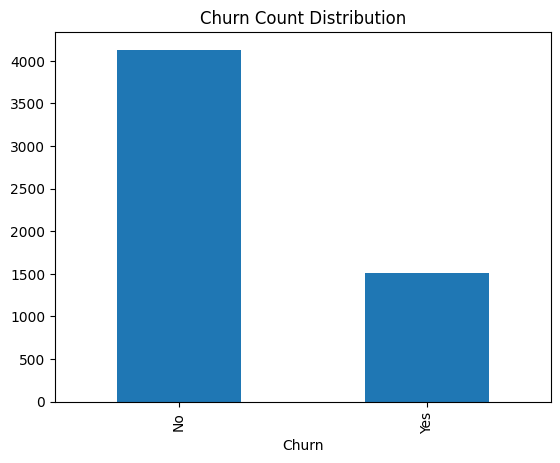

In [ ]:
train["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Count Distribution")
plt.show()


In [ ]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


,0
gender,169
OnlineSecurity,169


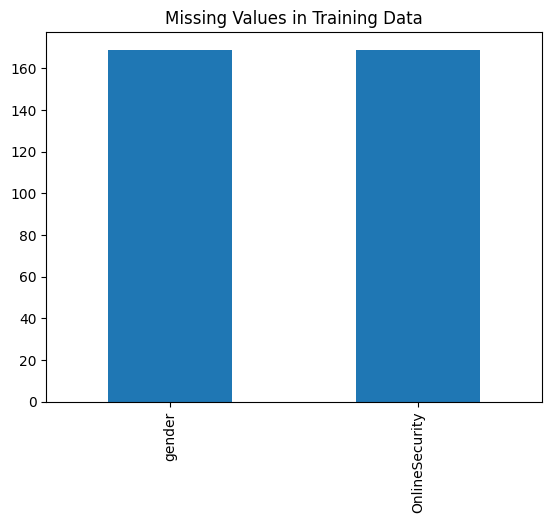

In [ ]:
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values in Training Data")
plt.show()


In [ ]:
num_cols = train.select_dtypes(exclude="object").columns
num_cols


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

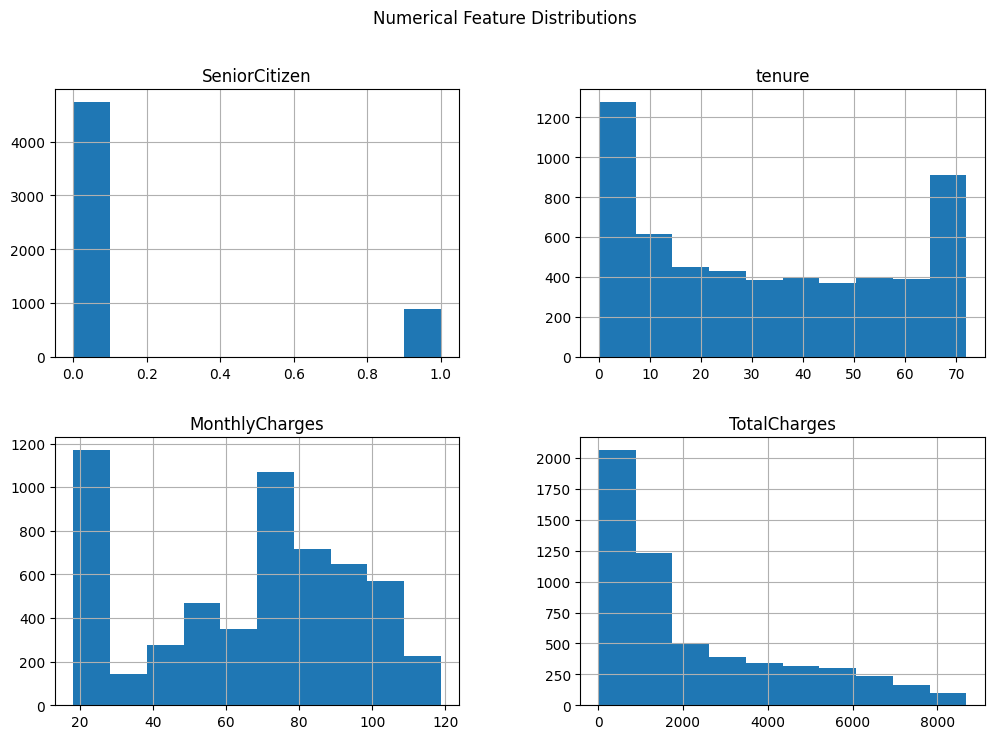

In [ ]:
train[num_cols].hist(figsize=(12,8))
plt.suptitle("Numerical Feature Distributions")
plt.show()


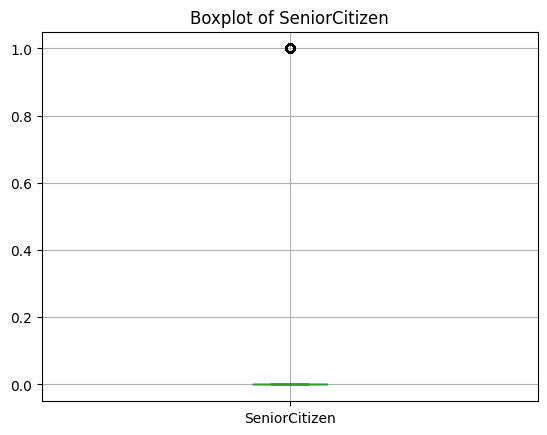

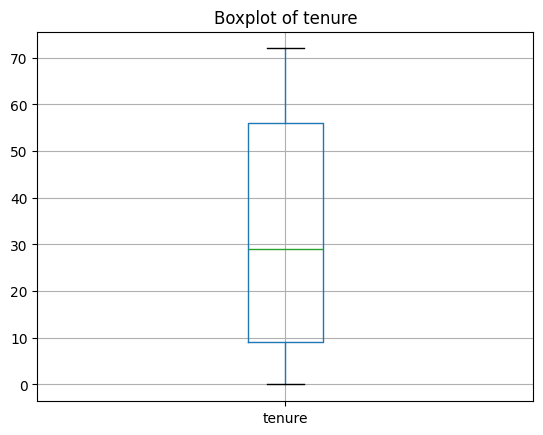

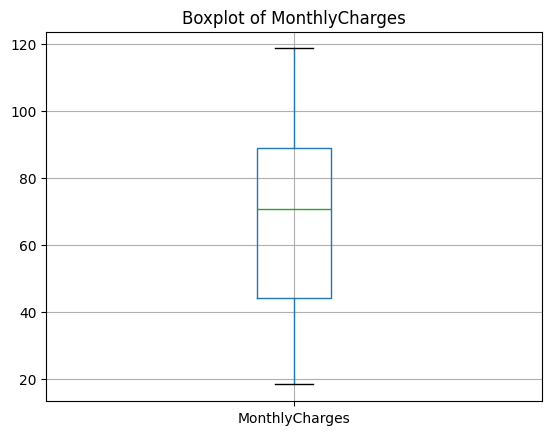

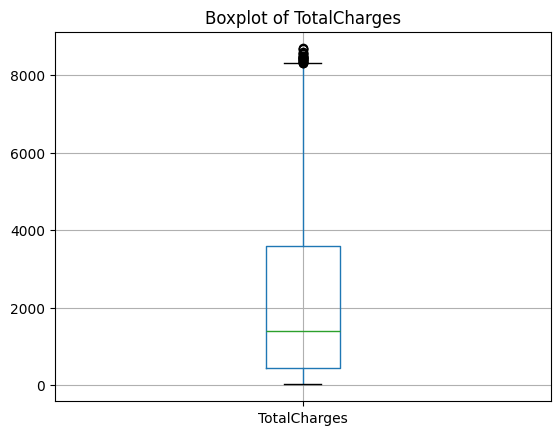

In [ ]:
for col in num_cols:
    plt.figure()
    train.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


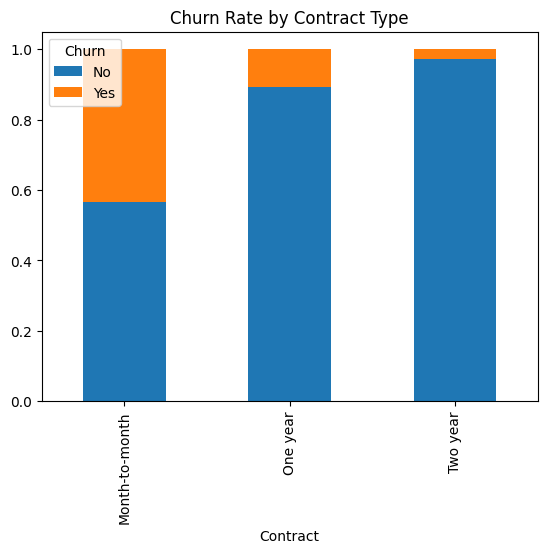

In [ ]:
pd.crosstab(train["Contract"], train["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract Type")
plt.show()


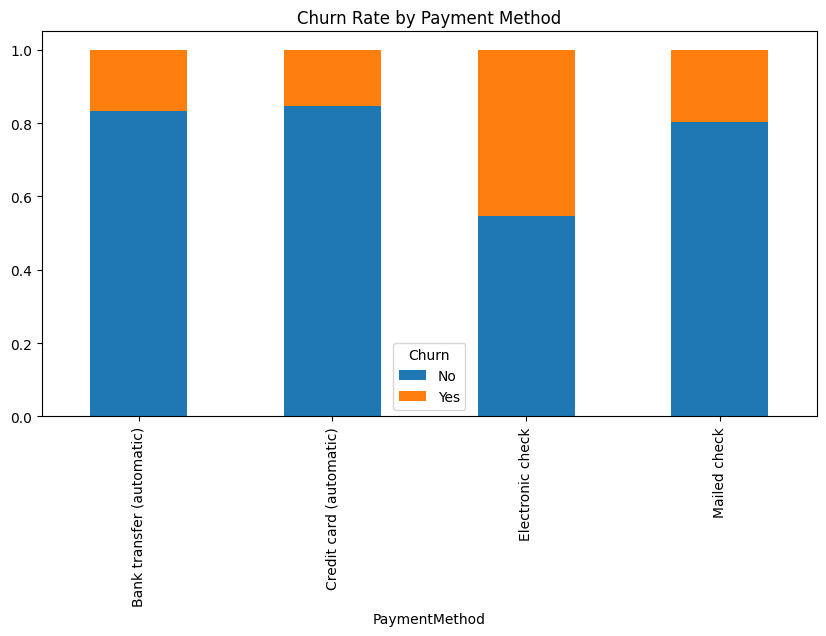

In [ ]:
pd.crosstab(train["PaymentMethod"], train["Churn"], normalize="index").plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Churn Rate by Payment Method")
plt.show()


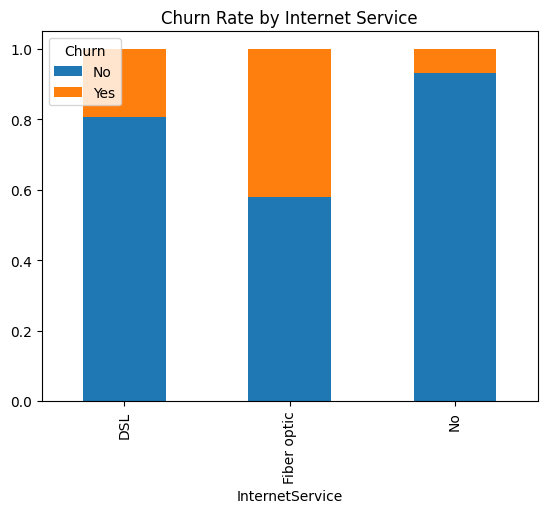

In [ ]:
pd.crosstab(train["InternetService"], train["Churn"], normalize="index").plot(kind="bar", stacked=True)
plt.title("Churn Rate by Internet Service")
plt.show()


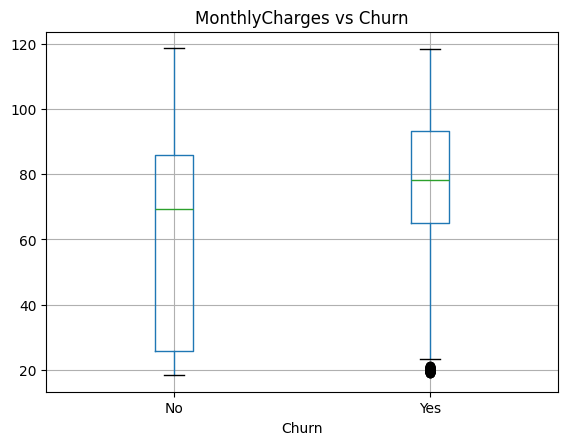

In [ ]:
train.boxplot(column="MonthlyCharges", by="Churn")
plt.title("MonthlyCharges vs Churn")
plt.suptitle("")
plt.show()


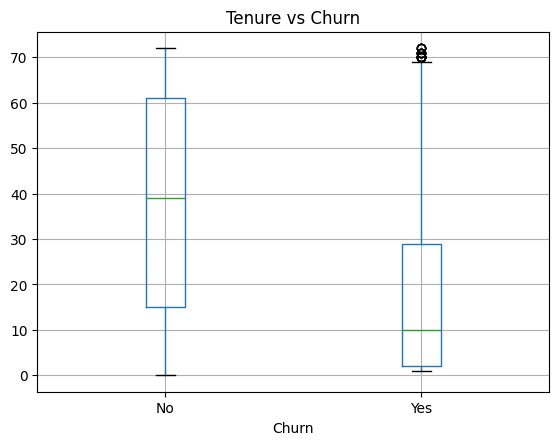

In [ ]:
train.boxplot(column="tenure", by="Churn")
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.show()


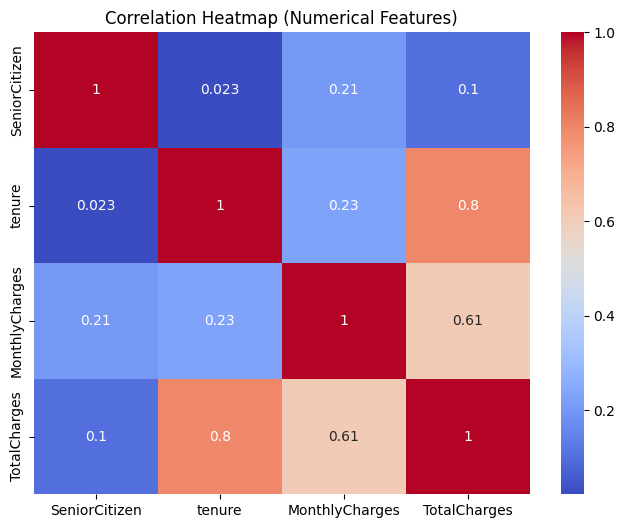

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()
